# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "ch3cl"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[550.0 548.0666666666667 546.1333333333334 ... 491.78333333333336 464.1 464.1] [550.0 548.0666666666666 552.7818181818182 ... 503.35 464.1 464.1] [550.0 551.3909090909091 557.1571428571428 ... 503.35 464.1 464.1] [550.0 548.8 547.5999999999999 ... 503.3500000000001 464.1 464.1] [550.0 548.0666666666667 546.5 ... 497.4515151515152 464.1 464.1] [550.0 548.0666666666667 546.1333333333333 ... 485.6545454545454 464.09999999999997 464.1]] [[540.0 543.6166666666667 547.2333333333333 ... 529.45 508.175 486.9] [540.0 543.6166666666667 547.4727272727273 ... 536.6333333333333 511.76666666666665 486.9] [540.0 543.7363636363636 547.0785714285714 ... 502.88749999999993 503.7479166666667 486.9] [540.0 542.940909090909 545.8818181818182 ... 520.5958333333333 508.175 486.9] [540.0 543.6166666666667 546.8954545454545 ... 529.4499999999999 508.17500000000007 486.9] [540.0 543.6166666666667 547.2333333333333 ... 529.45 508.17499999999995 486.9]] [[527.5 524.7 521.9000000000001 ... 541.775 531.0 526.3] [527.5 524.6999999999999 531.190909090909 ... 557.6333333333334 541.9666666666667 526.3] [527.5 529.3454545454546 541.3714285714286 ... 524.5 526.0222222222222 526.3] [527.5 530.9 534.3 ... 525.7444444444444 527.2666666666667 526.3] [527.5 524.7 525.0 ... 526.9888888888888 528.5111111111111 526.3] [527.5 524.7 521.9 ... 528.2333333333333 529.7555555555556 526.3]] ... [[547.8 551.5333333333333 555.2666666666667 ... 506.43333333333334 477.5 463.0] [547.8 551.5333333333333 557.4454545454545 ... 483.3 473.15 463.0] [547.8 552.6227272727273 555.3428571428572 ... 487.25 475.3888888888889 463.0] [547.8 542.5666666666666 537.3333333333334 ... 487.74074074074076 475.9166666666667 463.0] [547.8 551.5333333333333 550.7833333333333 ... 488.23148148148147 476.4444444444444 463.0] [547.8 551.5333333333333 555.2666666666667 ... 488.7222222222222 476.9722222222223 463.0]] [[547.2 547.3583333333333 547.5166666666667 ... 497.8625 464.275 449.0499999999999] [547.2 547.3583333333333 548.1428070175439 ... 496.3333333333333 472.6916666666666 449.0499999999999] [547.2 547.671403508772 549.0820175438597 ... 484.5 466.49722222222215 449.0499999999999] [547.2 541.2511904761906 535.302380952381 ... 482.3453703703704 465.94166666666666 449.0499999999999] [547.2 547.3583333333333 544.4630952380952 ... 480.19074074074075 465.38611111111106 449.0499999999999] [547.2 547.3583333333333 547.5166666666667 ... 478.0361111111111 464.8305555555555 449.0499999999999]] [[546.2 546.7 547.2 ... 497.5433333333333 474.82 473.02] [546.2 546.7 548.2600877192983 ... 469.9 471.46 473.02] [546.2 547.2300438596492 549.8502192982456 ... 506.0 487.87777777777774 473.02] [546.2 542.4428571428572 538.6857142857143 ... 500.6155555555556 484.61333333333334 473.02] [546.2 546.7 545.0714285714287 ... 495.2311111111111 481.3488888888889 473.02] [546.2 546.7 547.2 ... 489.84666666666664 478.08444444444444 473.02]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[550.0 548.0666666666667 546.1333333333334 ... 491.78333333333336 464.1 464.1] [550.0 548.0666666666666 552.7818181818182 ... 503.35 464.1 464.1] [550.0 551.3909090909091 557.1571428571428 ... 503.35 464.1 464.1] [550.0 548.8 547.5999999999999 ... 503.3500000000001 464.1 464.1] [550.0 548.0666666666667 546.5 ... 497.4515151515152 464.1 464.1] [550.0 548.0666666666667 546.1333333333333 ... 485.6545454545454 464.09999999999997 464.1]] [[540.0 543.6166666666667 547.2333333333333 ... 529.45 508.175 486.9] [540.0 543.6166666666667 547.4727272727273 ... 536.6333333333333 511.76666666666665 486.9] [540.0 543.7363636363636 547.0785714285714 ... 502.88749999999993 503.7479166666667 486.9] [540.0 542.940909090909 545.8818181818182 ... 520.5958333333333 508.175 486.9] [540.0 543.6166666666667 546.8954545454545 ... 529.4499999999999 508.17500000000007 486.9] [540.0 543.6166666666667 547.2333333333333 ... 529.45 508.17499999999995 486.9]] [[527.5 524.7 521.9000000000001 ... 541.775 531.0 526.3] [527.5 524.6999999999999 531.190909090909 ... 557.6333333333334 541.9666666666667 526.3] [527.5 529.3454545454546 541.3714285714286 ... 524.5 526.0222222222222 526.3] [527.5 530.9 534.3 ... 525.7444444444444 527.2666666666667 526.3] [527.5 524.7 525.0 ... 526.9888888888888 528.5111111111111 526.3] [527.5 524.7 521.9 ... 528.2333333333333 529.7555555555556 526.3]] ... [[547.8 551.5333333333333 555.2666666666667 ... 506.43333333333334 477.5 463.0] [547.8 551.5333333333333 557.4454545454545 ... 483.3 473.15 463.0] [547.8 552.6227272727273 555.3428571428572 ... 487.25 475.3888888888889 463.0] [547.8 542.5666666666666 537.3333333333334 ... 487.74074074074076 475.9166666666667 463.0] [547.8 551.5333333333333 550.7833333333333 ... 488.23148148148147 476.4444444444444 463.0] [547.8 551.5333333333333 555.2666666666667 ... 488.7222222222222 476.9722222222223 463.0]] [[547.2 547.3583333333333 547.5166666666667 ... 497.8625 464.275 449.0499999999999] [547.2 547.3583333333333 548.1428070175439 ... 496.3333333333333 472.6916666666666 449.0499999999999] [547.2 547.671403508772 549.0820175438597 ... 484.5 466.49722222222215 449.0499999999999] [547.2 541.2511904761906 535.302380952381 ... 482.3453703703704 465.94166666666666 449.0499999999999] [547.2 547.3583333333333 544.4630952380952 ... 480.19074074074075 465.38611111111106 449.0499999999999] [547.2 547.3583333333333 547.5166666666667 ... 478.0361111111111 464.8305555555555 449.0499999999999]] [[546.2 546.7 547.2 ... 497.5433333333333 474.82 473.02] [546.2 546.7 548.2600877192983 ... 469.9 471.46 473.02] [546.2 547.2300438596492 549.8502192982456 ... 506.0 487.87777777777774 473.02] [546.2 542.4428571428572 538.6857142857143 ... 500.6155555555556 484.61333333333334 473.02] [546.2 546.7 545.0714285714287 ... 495.2311111111111 481.3488888888889 473.02] [546.2 546.7 547.2 ... 489.84666666666664 478.08444444444444 473.02]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'ch3cl' (lon: 6, lat: 12, year: 26, month: 12)> Size: 180kB
<Quantity([[[[513.6        519.5        515.8        ... 570.4
    564.95       539.4       ]
   [524.15       516.6        517.05       ... 555.9
    551.7        525.2       ]
   [515.95       514.8        509.5        ... 549.3
    536.56666667 529.4       ]
   ...
   [509.53333333 505.25       514.03333333 ... 544.5
    537.66666667 514.4       ]
   [506.7        505.525      502.1        ... 535.15
    523.06666667 512.        ]
   [499.8        499.03333333 498.53333333 ... 545.
    529.23333333 523.25      ]]

  [[513.6        517.34795    521.3181     ... 575.5639
    564.95       545.16595   ]
   [524.15       516.29365    517.05       ... 563.4963
    552.91791667 529.4097    ]
   [515.95       509.09881667 510.0211     ... 544.30275
    535.24533333 522.06655   ]
...
   [527.38333333 542.5495     555.191      ... 483.87466667
    503.6375     519.39291667]
   [534.59433333 543.20783333 555.42625    ... 477.37825
    500.77225    514.78266667]
   [532.15625    539.09527778 545.078      ... 486.13955556
    500.992      518.19525   ]]

  [[550.35       562.96666667 570.13333333 ... 524.5
    536.         540.8       ]
   [555.125      574.4        577.9        ... 477.3
    516.         522.85      ]
   [548.6        557.6        567.8        ... 468.4
    493.4        516.375     ]
   ...
   [535.4245     545.4055     550.23533333 ... 485.562
    495.996      516.2805    ]
   [532.1285     543.037      555.03       ... 472.662
    498.08616667 509.941     ]
   [527.839      535.268      548.21966667 ... 476.4775
    497.128      520.997     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[513.6 519.5 515.8 ... 545.0 529.2333333333333 523.25] [513.6 517.3479500000001 521.3181000000001 ... 540.58695 529.6098666666667 525.6278333333333] [520.225 519.98975 527.7905000000001 ... 537.6347499999999 530.9159999999999 522.9891666666666] ... [572.35 584.7194444444444 594.4666666666667 ... 508.81391666666667 519.8814166666666 526.8625] [550.35 562.9666666666667 570.1333333333333 ... 482.2600000000001 497.25 512.4] [550.35 562.9666666666667 570.1333333333333 ... 475.93874999999997 497.144 521.761]] [[513.6 519.5 515.8 ... 545.0 529.2333333333333 523.25] [513.6 515.7499999999999 520.9999999999999 ... 540.1 529.3 527.2999999999998] [524.2071428571428 526.9785714285714 533.7714285714286 ... 538.0517857142858 529.6142857142856 529.047619047619] ... [542.5 569.9 590.2666666666667 ... 507.75 518.35 522.7] [550.35 562.9666666666667 570.1333333333333 ... 491.575 507.755 522.6125] [550.35 562.9666666666667 570.1333333333333 ... 475.4 497.16 522.525]] [[513.6 519.5 515.8 ... 545.0 529.2333333333333 523.25] [513.6 523.2392857142858 524.7857142857142 ... 540.4247352941177 527.436862745098 529.192] [522.2160714285715 534.4678571428572 537.5571428571428 ... 536.1742058823529 523.7772549019608 537.026] ... [543.4250000000001 567.3332205882352 590.2666666666667 ... 506.42050000000006 498.16 525.95] [550.35 562.9666666666667 570.1333333333333 ... 505.0499999999999 516.05 531.8] [550.35 562.9666666666667 570.1333333333333 ... 476.47749999999996 497.12800000000004 520.9970000000001]] [[513.6 519.5 515.8 ... 545.0 529.2333333333333 523.25] [513.6 524.094125 526.1073636363635 ... 543.4200625 529.3985416666667 527.6554375000001] [520.225 528.6882499999999 536.4147272727272 ... 541.840125 529.56375 532.060875] ... [544.35 564.7664411764706 590.2666666666667 ... 510.2423333333333 519.856 540.1025] [550.35 562.9666666666667 570.1333333333333 ... 493.89866666666666 508.476 529.78575] [550.35 562.9666666666667 570.1333333333333 ... 477.555 497.096 519.469]] [[513.6 519.5 515.8 ... 545.0 529.2333333333333 523.25] [513.6 520.54385 521.9543 ... 541.56085 530.2296 522.2835] [520.225 524.1618125 530.3441818181818 ... 539.29478125 530.9652708333333 523.1668854166667] ... [545.275 562.1996617647059 584.9186161616161 ... 509.76619444444435 519.8644722222222 535.6891666666666] [550.35 562.9666666666667 570.1333333333333 ... 490.01911111111116 504.734 523.9905] [550.35 562.9666666666667 570.1333333333333 ... 477.01625 497.112 520.2330000000001]] [[513.6 519.5 515.8 ... 545.0 529.2333333333333 523.25] [513.6 518.9459 521.6362 ... 541.0739 529.9197333333334 523.9556666666666] [520.225 521.5877 528.1086 ... 538.1217 531.2258666666667 521.3169999999999] ... [546.1999999999999 559.6328823529411 574.2225151515152 ... 509.2900555555555 519.8729444444444 531.2758333333334] [550.35 562.9666666666667 570.1333333333333 ... 486.1395555555556 500.992 518.19525] [550.35 562.9666666666667 570.1333333333333 ... 476.47749999999996 497.12800000000004 520.9970000000001]]]
Units,ppt


### Longitudinal-mean

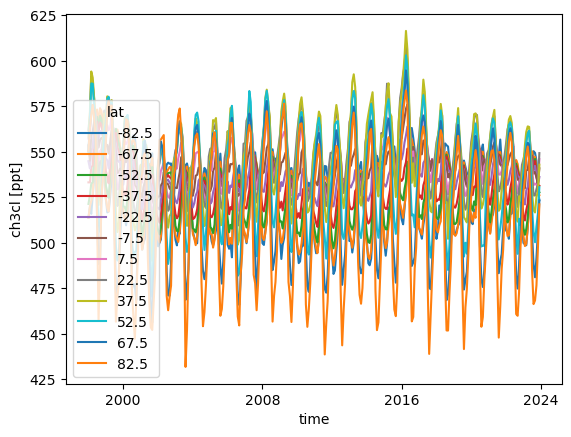

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

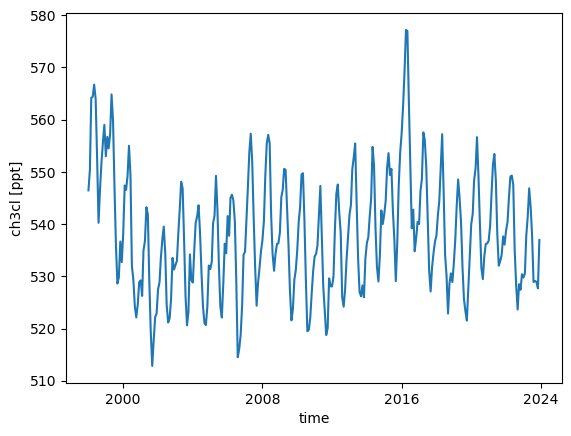

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

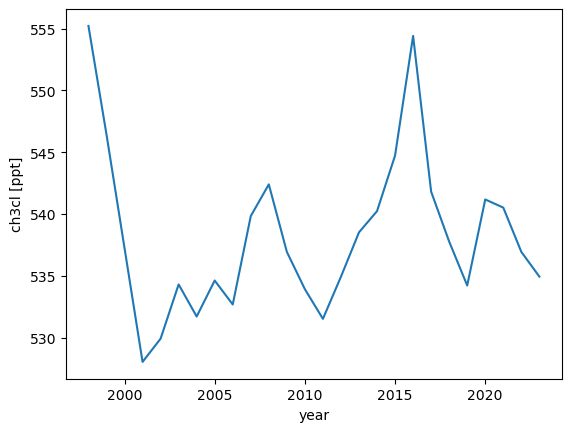

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 26)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 208B 1998 1999 2000 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3631 -0.273 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -28.51 ... -1.664e-14

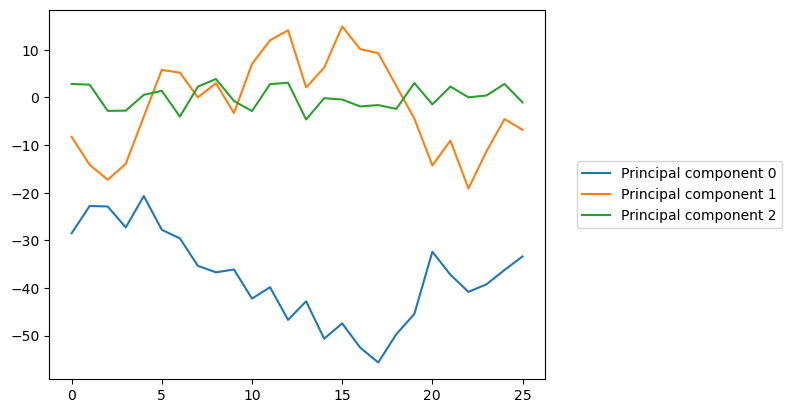

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

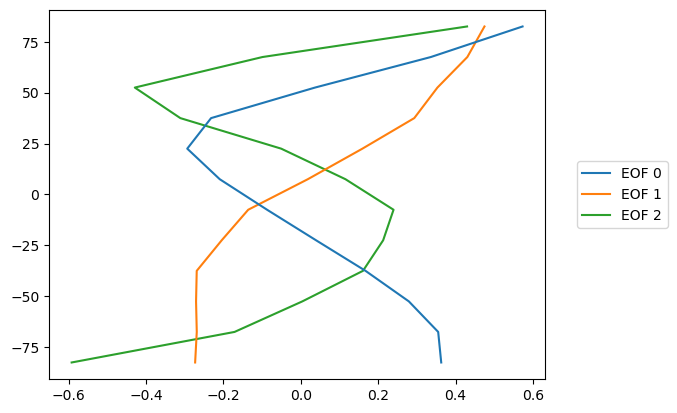

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

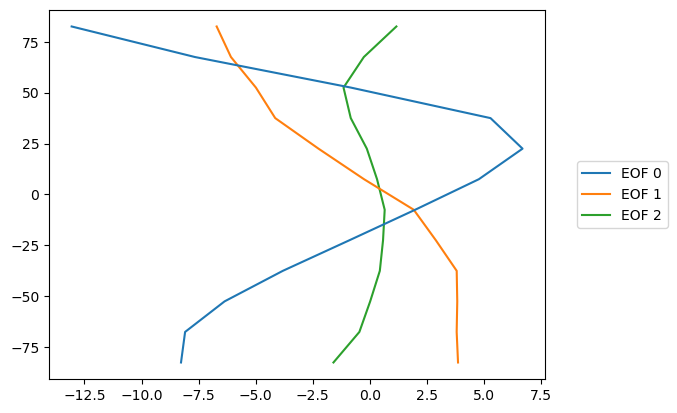

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3630825655437855] [0.3552313861325115] [0.2793943037047569] [0.1674136938256055] [0.03960651439132659] [-0.0870086639003578] [-0.20939049676035537] [-0.2933584475326751] [-0.2317853203723878] [0.03684086985665889] [0.33629171046332135] [0.5733032789675645]]
Units,ppt
Magnitude,[[-28.50846134695634] [-22.78493878343467] [-22.887709686177605] [-27.294388102889343] [-20.691822305570625] [-27.787923287737243] [-29.577445449129293] [-35.36094013134911] [-36.71277993430898] [-36.11748884499908] [-42.232102540328] [-39.844407306160974] [-46.70277948265733] [-42.79458115868617] [-50.658782701221384] [-47.44178788189257] [-52.534666306986686] [-55.64906696119889] [-49.716942653188866] [-45.46336856782468] [-32.39231267891987] [-37.21589724704873] [-40.82279074127528] [-39.23425898708574] [-36.2216647131602] [-33.37162795839035]]
Units,dimensionless


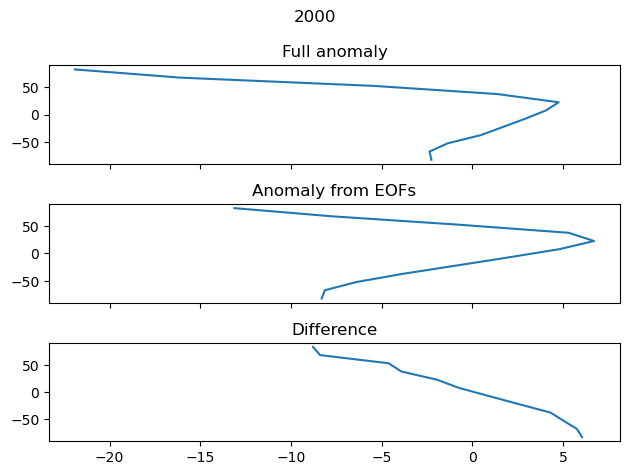

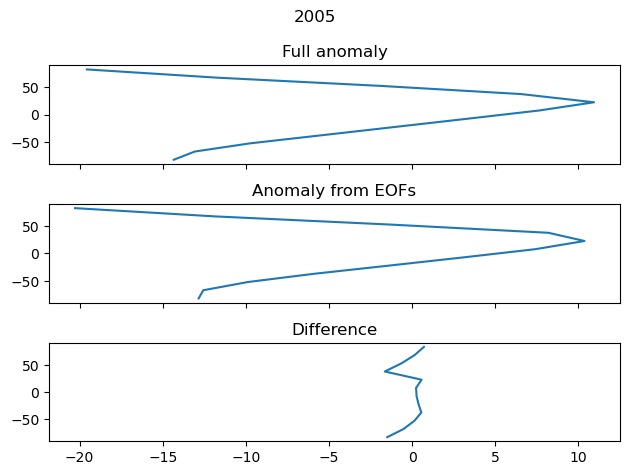

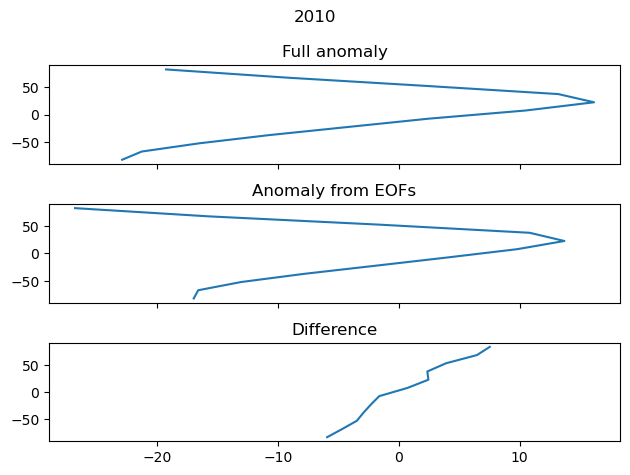

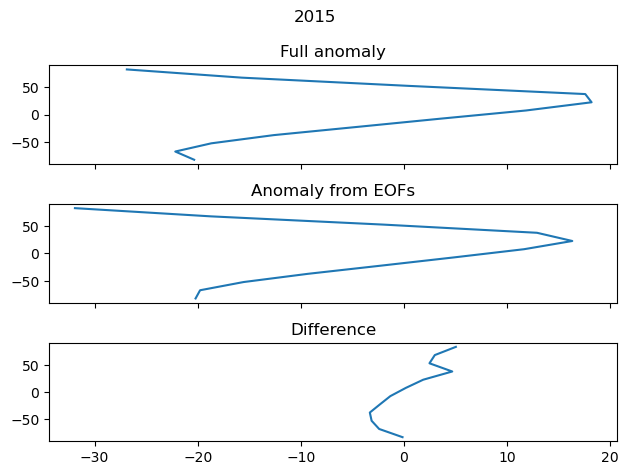

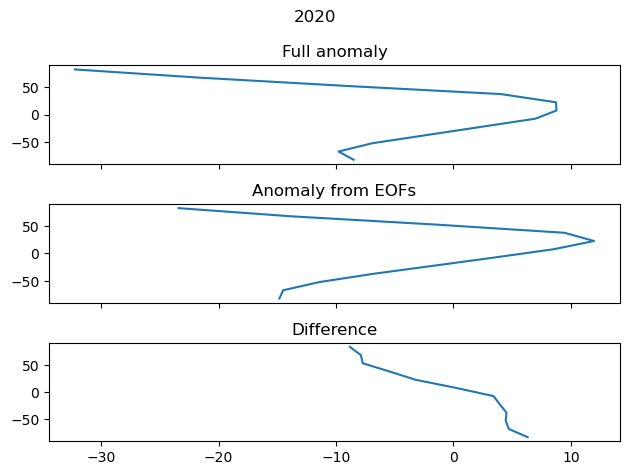

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 15273.20it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19253.23it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 18295.76it/s]

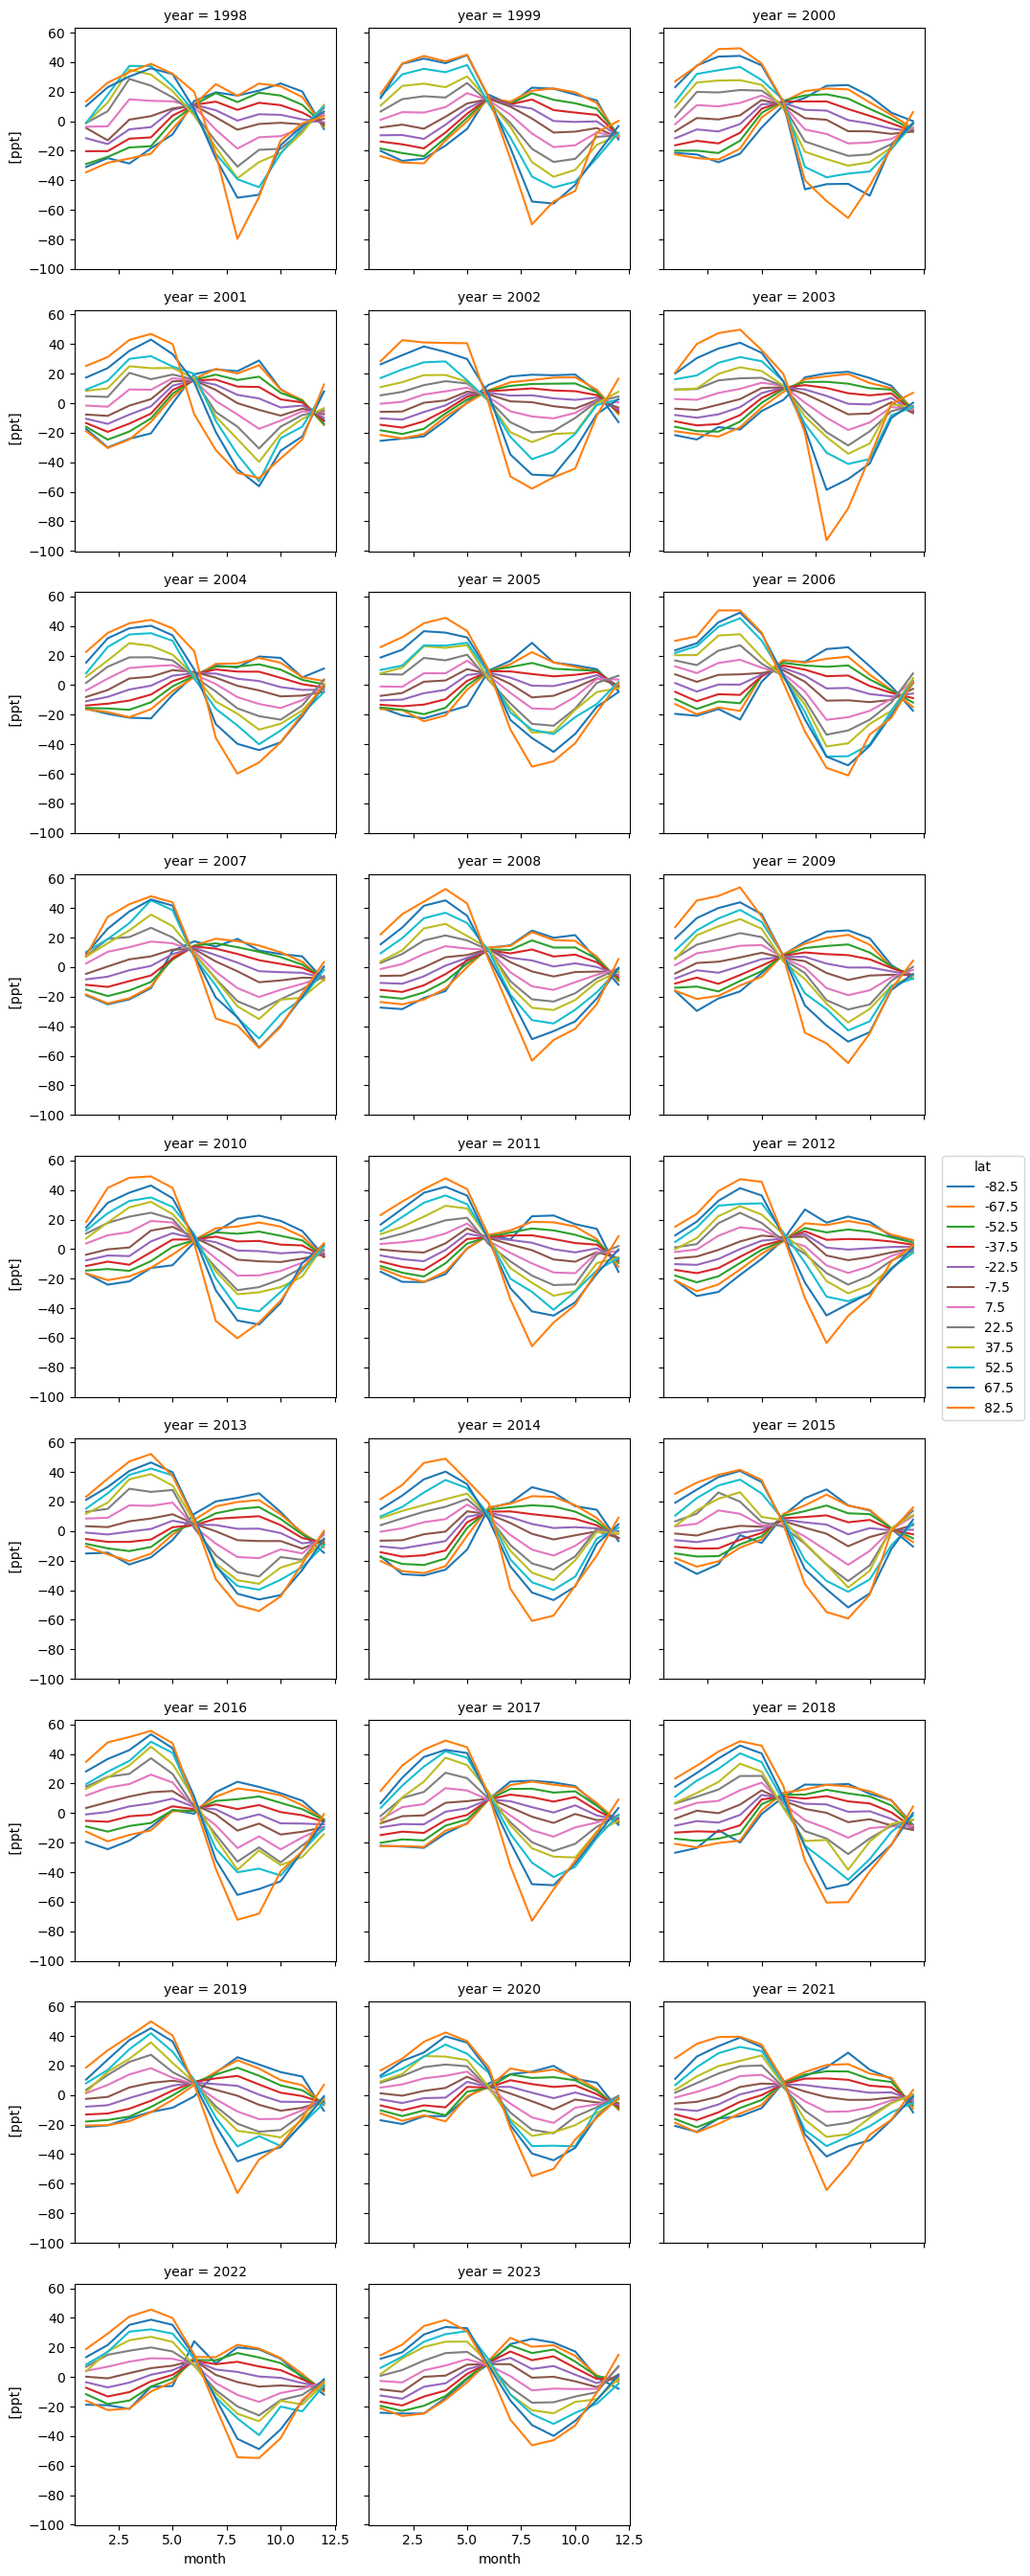

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

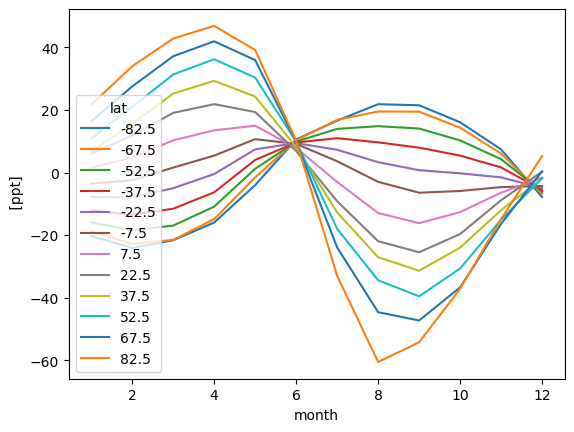

In [22]:
seasonality.plot.line(hue="lat")

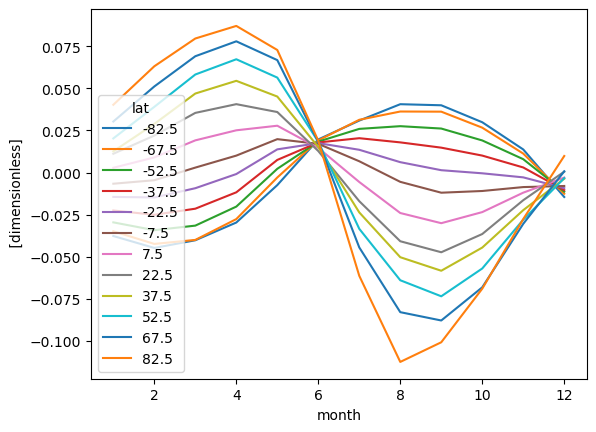

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[555.2186671658563 546.4387085364207 537.240105161473 528.0294402212761 529.9122504336083 534.3000851659713 531.7050312457364 534.6164333485946 532.6770921767347 539.8320315180378 542.3979645685021 536.9368531849921 533.9165668764326 531.5151263193435 534.9266077427117 538.5147571527698 540.2320960263972 544.731785931091 554.4117571988521 541.809541027353 537.7672944928761 534.2143217431307 541.1766584290312 540.5156454016588 536.9358810311585 534.9333087859761]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3630825655437855] [0.3552313861325115] [0.2793943037047569] [0.1674136938256055] [0.03960651439132659] [-0.0870086639003578] [-0.20939049676035537] [-0.2933584475326751] [-0.2317853203723878] [0.03684086985665889] [0.33629171046332135] [0.5733032789675645]]
Units,ppt
Magnitude,[[-28.50846134695634] [-22.78493878343467] [-22.887709686177605] [-27.294388102889343] [-20.691822305570625] [-27.787923287737243] [-29.577445449129293] [-35.36094013134911] [-36.71277993430898] [-36.11748884499908] [-42.232102540328] [-39.844407306160974] [-46.70277948265733] [-42.79458115868617] [-50.658782701221384] [-47.44178788189257] [-52.534666306986686] [-55.64906696119889] [-49.716942653188866] [-45.46336856782468] [-32.39231267891987] [-37.21589724704873] [-40.82279074127528] [-39.23425898708574] [-36.2216647131602] [-33.37162795839035]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.037698482178984596 -0.04478951159097205 -0.04022718736692517 -0.029694759900781072 -0.007481486813188984 0.019623860203334058 0.030828544527258837 0.04054869332941663 0.039909699617118634 0.0298376620636248 0.013683194356094374 -0.014540239085806088] [-0.034870136687027035 -0.04240761035413389 -0.04002604393938326 -0.02765908125947875 -0.002961492506785054 0.019075766167099214 0.031291901431674304 0.03620397764337694 0.03611574881737075 0.02661822860389556 0.011235060925653862 -0.012616328226280456] [-0.02959703131932605 -0.034236920311954716 -0.031536787595189714 -0.020245560006081388 0.002198835678217236 0.018345538018870195 0.02589562098378993 0.02750162601546597 0.026095661216788427 0.019029776065346487 0.007909291770437381 -0.011360055500446345] [-0.022546115499641292 -0.025103603619362296 -0.021483326309534864 -0.011763929129046663 0.00747139374163065 0.017838408059754948 0.02036393587258236 0.017880847027772366 0.014750408232958869 0.01004173742302333 0.0029935592183032065 -0.010443317783238166] [-0.014492159507894987 -0.01480806857908053 -0.009324931453532293 -0.0009125028598077257 0.013738540917391287 0.01744571241474936 0.013487861501950355 0.006134506463055304 0.0013689473585468234 -0.0004766698670209252 -0.002883605422301689 -0.009277632981223019] [-0.006660661338523161 -0.004587913430289354 0.002909459499751961 0.010027396663633276 0.01980115177110221 0.01700967485914996 0.006672693844210053 -0.00554624702156955 -0.011992884597739627 -0.010976665637676566 -0.008652532559795558 -0.00800347318797442] [0.0027985962142373995 0.00895005154111969 0.019083167707537707 0.025051168457305706 0.027772315943446823 0.014614732543916067 -0.005645613062384031 -0.02405251086639783 -0.030086435612374333 -0.023509334408235032 -0.01197130589710766 -0.0030048295185902013] [0.011123897283404014 0.02192872723059693 0.0353876832387423 0.040573932613399206 0.035898253697909666 0.01274376632816626 -0.017026776380870273 -0.04080606679676162 -0.04734475015890735 -0.03652367497830947 -0.016444906351823243 0.0004899171520152427] [0.012547811490670318 0.028839095077191346 0.046878475297253856 0.05442712365507494 0.045092255185850645 0.015120364331770761 -0.023690716791149802 -0.050287324687904526 -0.05832374380436668 -0.0445713118432853 -0.022352351895171298 -0.003679682983261903] [0.020234047808351176 0.03897321618728825 0.05817178031786716 0.06722705906840075 0.05634200050538524 0.018296443074525034 -0.033435240142389515 -0.06396599991997043 -0.07348685292892354 -0.056986627895098826 -0.028017469861493293 -0.0033523635062893526] [0.0302568993847406 0.05107623088965809 0.06902101169683486 0.07787864851728359 0.06672124907128668 0.0182360195636331 -0.04448015496127762 -0.08291233095676317 -0.08785531209097684 -0.06816914181535089 -0.03047272896337159 0.0006996076914941486] [0.04020177965574373 0.06306243289199889 0.0795458024665798 0.08701893475290443 0.0727367154793783 0.018822454012488228 -0.061343002317240464 -0.11245037019060887 -0.1007844284495995 -0.06897091642031322 -0.027630822922429014 0.009791432908002788]]
Units,dimensionless
